In [14]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [15]:
#===========================================
# Load File 1
#===========================================

with open('../../../01_Benchmark/Data/Sample_Banana_BIS_MMD.npy', 'rb') as f:
    sample_losses_01_halton = jnp.load(f)

with open('Sample_Banana_BIS_MMD.npy', 'rb') as f:
    sample_losses_01_random = jnp.load(f)
    
sample_losses_01_list = [ sample_losses_01_halton, sample_losses_01_random ]


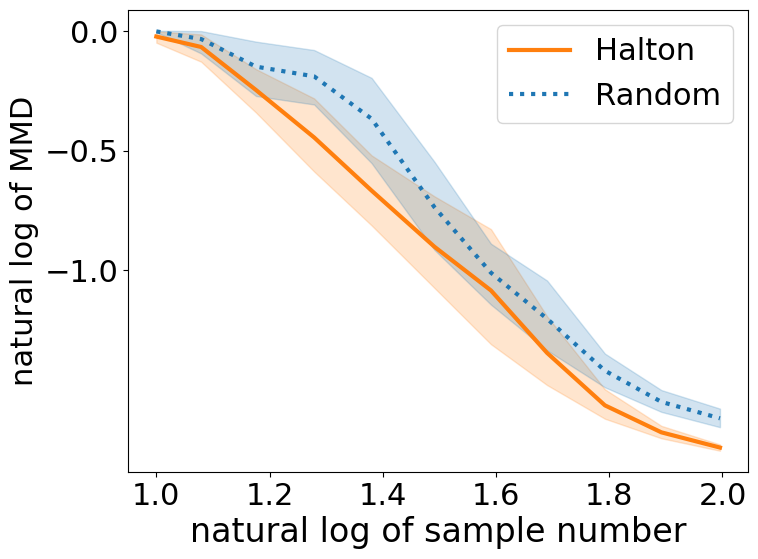

In [16]:
#===========================================
# Visualise Sample Losses
#===========================================

def plot_sample_loss(loss_list, init_num=10, total_num=100, ytick=None, xlabel=True, ylabel=True, legend=True):
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    loss_index = jnp.log10( jnp.array([10, 12, 15, 19, 24, 31, 39, 49, 62, 78, 99]) )
    df_halton = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[0].flatten())})
    df_random = pd.DataFrame({'index': jnp.tile(loss_index,10), 'loss': jnp.log10(loss_list[1].flatten())})

    sns.lineplot(df_halton, x='index', y='loss', ax=ax, linestyle='solid', linewidth=3, color=sns.color_palette()[1], label="Halton")
    sns.lineplot(df_random, x='index', y='loss', ax=ax, linestyle='dotted', linewidth=3, color=sns.color_palette()[0], label="Random")

    if ytick:
        ax.set_yticks(ytick)
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.set_xlabel("natural log of sample number", fontsize=24) if xlabel else ax.set_xlabel(" ", fontsize=22)
    ax.set_ylabel("natural log of MMD", fontsize=22) if ylabel else ax.set_ylabel(" ", fontsize=22)
    ax.legend(prop=dict(size=22)) if legend else ax.get_legend().remove()

plot_sample_loss(sample_losses_01_list, ytick=[0.0, -0.5, -1.0])
